In [1]:
!pip3 install matplotlib pandas &> /dev/null # Do not expose PII

In [19]:
import matplotlib.pyplot as plt
from legend import draw_legend

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.default"] = "sf"
plt.rcParams["font.size"] = 8
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["legend.fontsize"] = 6
plt.rcParams["legend.framealpha"] = 0.95
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["lines.linewidth"] = 1
plt.rcParams["lines.markersize"] = 2
plt.rcParams["axes.linewidth"] = 0.5
plt.rcParams["xtick.major.width"] = 0.5
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["font.sans-serif"] = ["Times New Roman"]
plt.rcParams["hatch.linewidth"] = 0.5
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
plt.rcParams["mathtext.it"] = "Times New Roman:italic"
plt.rcParams["mathtext.bf"] = "Times New Roman:bold"

LINEWIDTH = 252 / 72 # \linewidth from pts to inches
HEIGHT = LINEWIDTH / 2.5

In [ ]:
import pandas as pd

import re
import math
from datetime import timedelta

def normalize(x):
    group = re.search(r"\.\d+ ", x)
    if group != None:
        return x[:group.end()-1].ljust(26, "0")
    else:
        return x[:19] + ".000000"

def resample(df, resample_method="mean", resample_factor=100):
    df["time"] = df["time"].apply(normalize)
    df["time"] = pd.to_datetime(df["time"], format="%Y-%m-%d %H:%M:%S.%f")
    df = df.sort_values(by="time")

    time_range_in_us = (df["time"].max() - df["time"].min()) / timedelta(microseconds=1)
    resample_rate = round(time_range_in_us / resample_factor)

    df = df.set_index("time")
    if resample_method == "mean":
        df = df.resample(f"{resample_rate}us").mean()
        df = df.interpolate()
    elif resample_method == "min":
        df = df.resample(f"{resample_rate}us").min()

    df = df.reset_index()

    start = df.iloc[0]
    df["start"] = start["time"]
    df["time"] = df["time"] - df["start"]

    df = df.dropna()

    df["time"] = df["time"].astype("int64")

    return df, resample_rate

# Memory usage

In [20]:
import pandas as pd
import re
import matplotlib
import matplotlib.ticker as mtick
import math

def plot_memory(df, base=100_000, fig=None, color="tab:green", linestyle="-", name="", marker=""):
    if fig != None:
        fig, ax = fig, fig.get_axes()[0]
    else:
        fig, ax = plt.subplots(1, figsize=(LINEWIDTH, HEIGHT), layout="constrained")
    
    df["memory"] = df["memory"] / 1024**2
    entry_count = df.shape[0]
    highest = df["alerts"].max()

    print(name)
    print(f"#alerts = {highest}")
    print(f"max = {df['memory'].max()}")
    print(f"mean = {df['memory'].mean()}")
    print(f"final = {df['memory'].iloc[-1]/1024} GB")

    df, _ = resample(df, resample_factor=60)

    df["alerts"] /= highest


    ax.plot(df["alerts"], df["memory"], linestyle=linestyle, marker=marker, color=color, label=name + f' ({highest/1000:,.0f}k)')
    ax.set_ylabel("Memory [MB]")
    ax.set_xlabel("Cumulative alerts [%]")

    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
    y_limit_max = 2500
    ax.yaxis.set_major_locator(mtick.MultipleLocator(base=y_limit_max/5))
    ax.yaxis.set_minor_locator(mtick.MultipleLocator(base=y_limit_max/10))
    ax.xaxis.set_minor_locator(mtick.MultipleLocator(base=0.05))
    ax.xaxis.set_major_locator(mtick.MultipleLocator(base=0.1))

    ax.set_axisbelow(True)
    ax.grid(which="major", axis="y", linestyle="-", linewidth="0.25")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, y_limit_max])

    return fig

CIC-IDS2017
#alerts = 23855
max = 6.5390625
mean = 5.360481770833333
final = 0.005615234375 GB
CIC-IDS2017-$\it{Perf}$
#alerts = 8578038
max = 2765.5703125
mean = 955.7940031322844
final = 1.7251739501953125 GB
CSE-CIC-IDS2018
#alerts = 396141
max = 831.0234375
mean = 461.7519433103015
final = 0.8115463256835938 GB
CSE-CIC-IDS2018-APT
#alerts = 452301
max = 669.421875
mean = 394.6463036894273
final = 0.6537322998046875 GB


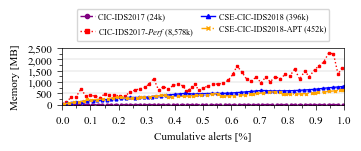

In [ ]:
fig_memory = plot_memory(pd.read_csv("../../results/alerts/ids2017/memory.csv"), color="purple", name="CIC-IDS2017", linestyle="--", marker="o")
fig_memory = plot_memory(pd.read_csv("../../results/alerts/ids2017-perf/memory.csv"), fig=fig_memory, color="red", name=r"CIC-IDS2017-$\it{Perf}$", linestyle=":", marker="s")
fig_memory = plot_memory(pd.read_csv("../../results/alerts/ids2018/memory.csv"), fig=fig_memory, color="blue", name="CSE-CIC-IDS2018", linestyle="-", marker="^")
fig_memory = plot_memory(pd.read_csv("../../results/alerts/ids2018-apt/memory.csv"), fig=fig_memory, color="orange", name="CSE-CIC-IDS2018-APT", linestyle="-.", marker="x")

ax = fig_memory.get_axes()[0]
ax.yaxis.set_label_coords(-0.15, 0.5)

draw_legend(ax, ncol=2, horizontal_position=0.5)

In [ ]:
fig_memory.savefig("../../results/figures/memory-performance.pdf", transparent=True)

# CPU Performance

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


def preprocess_difference(df, series_selector="alerts"):
    print(f"min = {df[series_selector].min()}")
    print(f"max = {df[series_selector].max()}")
    print(f"mean = {df[series_selector].mean()}")

    df, resample_rate = resample(df, resample_factor=50)

    df[series_selector] = df[series_selector].diff(periods=-1) * -1
    df[series_selector] = df[series_selector] * ((timedelta(seconds=1) / timedelta(microseconds=1)) / resample_rate)
    df = df.iloc[:-1]

    return df

def plot_alerts(df, base_x=1, fig=None, name="", color="blue", marker="", linestyle="-", series_selector="alerts"):
    if fig == None:
        fig, ax = plt.subplots(figsize=(LINEWIDTH, HEIGHT), layout="constrained")
    else:
        ax = fig.get_axes()[0]
    
    time_series = df["time"].apply(normalize)
    time_series = pd.to_datetime(time_series, format="%Y-%m-%d %H:%M:%S.%f")
    duration = time_series.iloc[-1] - time_series.iloc[0]
    print(f"total time: {duration}")

    df = preprocess_difference(df, series_selector)
    time = df["time"] / df["time"].max()

    y_limit_max = df[series_selector].max()
    _, old_y_limit_max = ax.get_ylim()

    if old_y_limit_max < y_limit_max:
        ax.set_ylim(0, y_limit_max*1.05)

    handles = []

    #y_label = "$\\sfrac{\\text{Alerts}}{\\text{s}}$"
    y_label = "Alerts/s"
    length = duration.total_seconds()
    plot, = ax.plot(time, df[series_selector], label=f"{name} ({length:,.1f}s)", marker=marker, color=color, linestyle=linestyle)
    handles.append(plot)
    
    ax.set_xlabel("Relative time [%]")
    ax.set_ylabel(y_label)

    ax.set_xlim(0, 1.0)

    return fig


total time: 0 days 00:00:00.242908
min = 0
max = 23855
mean = 11949.8125
total time: 0 days 00:01:04.912608
min = 0
max = 8578038
mean = 4289499.887878788
total time: 0 days 00:00:03.330434
min = 0
max = 396141
mean = 198497.84170854272
total time: 0 days 00:00:02.362205
min = 0
max = 452301
mean = 226498.4603524229


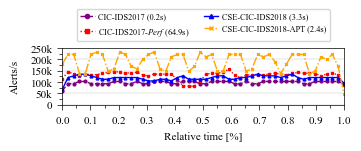

In [ ]:
fig_alerts = plot_alerts(pd.read_csv("../../results/alerts/ids2017/alerts.csv"), color="purple", name="CIC-IDS2017", linestyle="--",  marker="o")
fig_alerts = plot_alerts(pd.read_csv("../../results/alerts/ids2017-perf/alerts.csv"), color="red",fig=fig_alerts, name=r"CIC-IDS2017-$\it{Perf}$", linestyle=":", marker="s")
fig_alerts = plot_alerts(pd.read_csv("../../results/alerts/ids2018/alerts.csv"), color="blue", fig=fig_alerts, name="CSE-CIC-IDS2018", linestyle="-", marker="^")
fig_alerts = plot_alerts(pd.read_csv("../../results/alerts/ids2018-apt/alerts.csv"), color="orange", fig=fig_alerts, name="CSE-CIC-IDS2018-APT", linestyle="-.", marker="x")

ax = fig_alerts.get_axes()[0]

ax.yaxis.set_major_locator(mtick.MultipleLocator(base=50000))
ax.yaxis.set_minor_locator(mtick.MultipleLocator(base=25000))
ax.xaxis.set_minor_locator(mtick.MultipleLocator(base=0.05))
ax.xaxis.set_major_locator(mtick.MultipleLocator(base=0.1))
ax.yaxis.set_label_coords(-0.15, 0.5)
ax.yaxis.set_major_formatter(lambda x, pos: f'{x/1000:,.0f}k' if x != 0 else 0)
ax.grid(linestyle="-", which="major", axis="y", linewidth=0.25)
ax.set_ylim(0, 250_000)

draw_legend(ax, ncol=2, columnspacing=1.75, horizontal_position=0.5)

In [ ]:
fig_alerts.savefig("../../results/figures/cpu-performance.pdf", transparent=True)